***Lab Work 3 and Lab Work 4***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from varclushi import VarClusHi
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


**TASK 1**

In [2]:
df = pd.read_csv('baseball.csv',index_col='Name')
# df.dtypes

**TASK 2**

*Обработка пропусков. Переменная Salary (и log Salary) может содержать пропуски, произведите подстановку пропусков методом KnnImputer (neighbors=5). Пересчитайте logSalary как log(1+Salary), чтобы получить более симметричное распределение.*

In [3]:
missing_values = df[df['Salary'].isna()]['Salary']

knnImp = KNNImputer(n_neighbors=5) 
reload_missing = knnImp.fit_transform(X=df[['Salary']])

df['Salary'] = reload_missing
df['logSalary'] = np.log(1+df['Salary'])

df['logSalary']

Name
Allanson, Andy       6.285860
Ashby, Alan          6.165418
Davis, Alan          6.175867
Dawson, Andre        6.216606
Galarraga, Andres    4.527209
                       ...   
McGee, Willie        6.552508
Randolph, Willie     6.775366
Tolleson, Wayne      5.955837
Upshaw, Willie       6.867974
Wilson, Willie       6.908755
Name: logSalary, Length: 322, dtype: float64

**TASK 3**

*Нормализация переменных – приведите числовые переменные к близким шкалам с помощью метода MaxAbsScaler и закодируйте категориальные с помощью OneHotEncoder.*

In [4]:
cat_cols = ['Team','League','Division','Position', 'Div']
df_task3 = df.copy()
num_cols = [col for col in df.columns if col not in cat_cols]

scaler = MaxAbsScaler()

df_task3[num_cols] = scaler.fit_transform(X=df[num_cols])
df_encoded = pd.get_dummies(df_task3, columns=cat_cols,drop_first=True)

df_encoded

,nAtBat,nHits,nHome,nRuns,nRBI,nBB,YrMajor,CrAtBat,CrHits,CrHome,...,Position_OD,Position_OF,Position_OS,Position_RF,Position_S3,Position_SS,Position_UT,Div_AW,Div_NE,Div_NW
Name,,,,,,,,,,,,,,,,,,,,,
"Allanson, Andy",0.426492,0.277311,0.025,0.230769,0.239669,0.133333,0.041667,0.020850,0.015508,0.001825,...,False,False,False,False,False,False,False,False,False,False
"Ashby, Alan",0.458515,0.340336,0.175,0.184615,0.314050,0.371429,0.583333,0.245428,0.196194,0.125912,...,False,False,False,False,False,False,False,False,False,True
"Davis, Alan",0.697234,0.546218,0.450,0.507692,0.595041,0.723810,0.125000,0.115563,0.107378,0.114964,...,False,False,False,False,False,False,False,True,False,False
"Dawson, Andre",0.721980,0.592437,0.500,0.500000,0.644628,0.352381,0.458333,0.400484,0.370066,0.410584,...,False,False,False,True,False,False,False,False,True,False
"Galarraga, Andres",0.467249,0.365546,0.250,0.300000,0.347107,0.285714,0.083333,0.028179,0.023731,0.021898,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"McGee, Willie",0.723435,0.533613,0.175,0.500000,0.396694,0.352381,0.208333,0.192343,0.189380,0.058394,...,False,False,False,False,False,False,False,False,True,False
"Randolph, Willie",0.716157,0.571429,0.125,0.584615,0.413223,0.895238,0.500000,0.392158,0.355028,0.071168,...,False,False,False,False,False,False,False,False,False,False
"Tolleson, Wayne",0.691412,0.529412,0.075,0.469231,0.355372,0.495238,0.250000,0.120971,0.101739,0.012774,...,False,False,False,False,False,False,False,True,False,False


**TASK 4**

*С помощью восходящей иерархической кластеризации с выбранными параметрами расстояния link=average, dist=euclidean постройте кластерную модель данных и дендрограмму для топ 20 кластеров.*

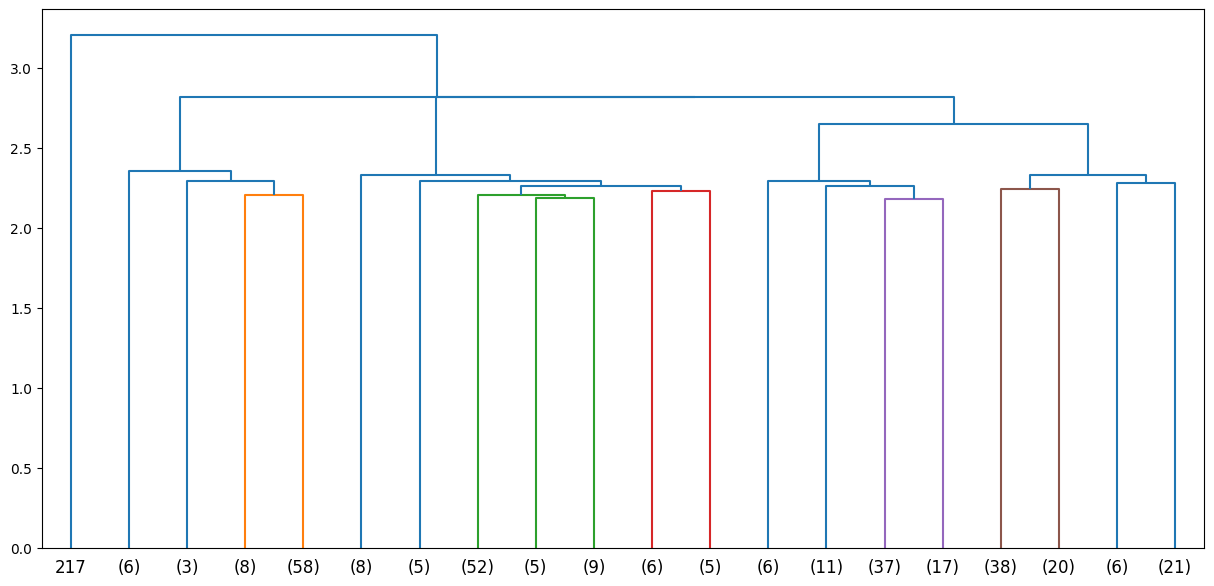

In [5]:
linkage_matrix = linkage(df_encoded,method='average')
plt.figure(figsize=(15,7))

dendrogram(linkage_matrix,truncate_mode='lastp',p=20)
distance_threshold = sorted(linkage_matrix[:,2])[-20]

cluster_labels = fcluster(linkage_matrix, t=20, criterion='maxclust') - 1

# plt.figure(figsize=(15,7))
# aggClus = AgglomerativeClustering(n_clusters=5,linkage='average',metric='euclidean')
# aggClus.fit(df_encoded)

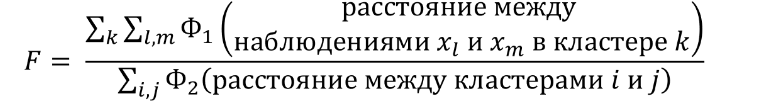

**TASK 5**

*Рассчитайте значение критерия pseudoF для вариантов кластеризации 2-20 кластеров, постройте график зависимости критерия от числа кластеров и выберите оптимальное (первый локальный пик критерия при обходе от малого числа кластеров к большому). Отметьте точку*

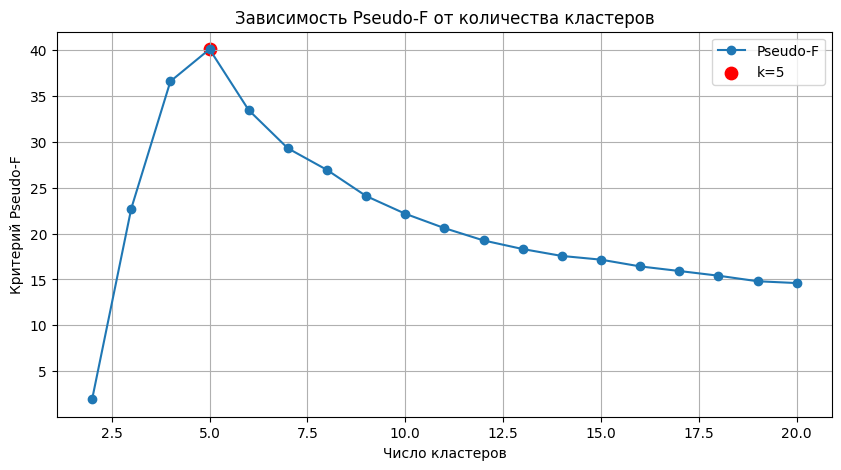

Оптимальное количество кластеров: 5


In [6]:
from scipy.signal import argrelextrema

def sum_dist_to_center(X):
    center = np.mean(X, axis=0)
    return ((X - center) ** 2).sum()

def choose_num_clusters_ahc(X, min_clust=2, max_clust=20):
    N = X.shape[0]
    Q = sum_dist_to_center(X)
    pseudo_f = []

    for G in range(min_clust, max_clust + 1):
        clustering = AgglomerativeClustering(
            n_clusters=G,
            linkage='average',
            metric='euclidean'
        )
        labels = clustering.fit_predict(X)
        W = 0
        for l in range(G):
            elems = X[labels == l]
            W += sum_dist_to_center(elems)
        fisher_stat = ((Q - W) / (G - 1)) / (W / (N - G))
        pseudo_f.append(fisher_stat)

    pseudo_f = np.array(pseudo_f)
    cluster_range = np.arange(min_clust, max_clust + 1)


    local_maxima = argrelextrema(pseudo_f, np.greater)[0]
    if len(local_maxima) > 0:
        best_index = local_maxima[0]
    else:
        best_index = np.argmax(pseudo_f)

    k = cluster_range[best_index]

    plt.figure(figsize=(10, 5))
    plt.plot(cluster_range, pseudo_f, marker='o', label='Pseudo-F')
    plt.scatter(k, pseudo_f[best_index], color='red', s=80, label=f'k={k}')
    plt.xlabel('Число кластеров')
    plt.ylabel('Критерий Pseudo-F')
    plt.title('Зависимость Pseudo-F от количества кластеров')
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f'Оптимальное количество кластеров: {k}')
    return k

optimal_clusters = choose_num_clusters_ahc(df_encoded.values)

*Индекс Калински – Харабаса вычисляется как отношение сумм межкластерных отклонений 𝐵 к суммам внутрикластерных отклонений 𝑊, нормированных на
количество их степеней свободы. Большие значения индекса Калински – Харабаса показывают, что кластеры разделены хорошо и расположены далеко друг от друга*

**TASK 6**

*С помощью метода PCA постройте отображение на плоскость, цветом точки укажите номер кластера.*

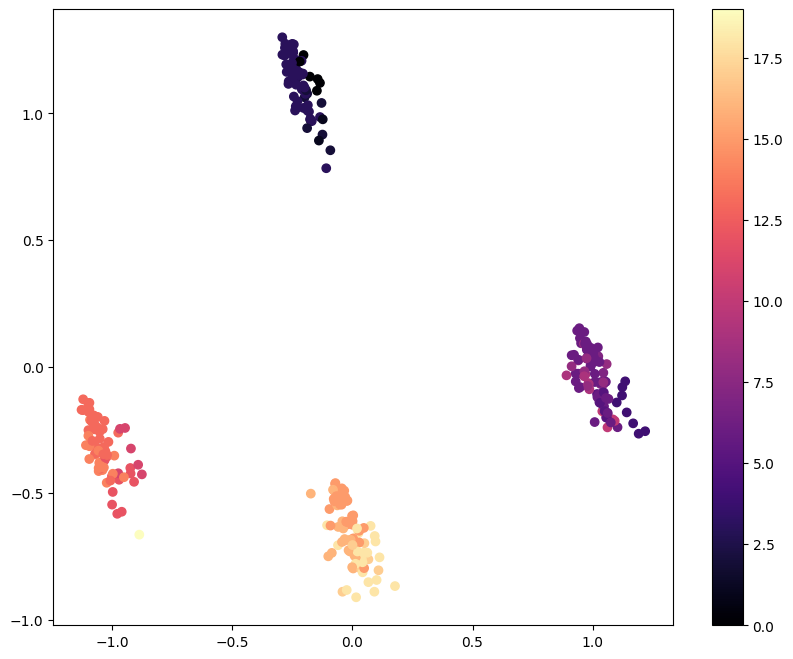

In [7]:
pca_model = PCA(n_components=2,random_state=np.random.seed(42))

W = pca_model.fit_transform(df_encoded.values)
H = pca_model.components_

fig = plt.figure(figsize=(10, 8))
plt.scatter(*W.T,c=cluster_labels, cmap="magma")
plt.colorbar()

**TASK 7**

*Выполните кластеризацию сферическими кластерами с прототипом методом KMeans, также постройте проекцию как на шаге 6, определите наиболее типичного представителя (по имени) в каждом из кластеров.*

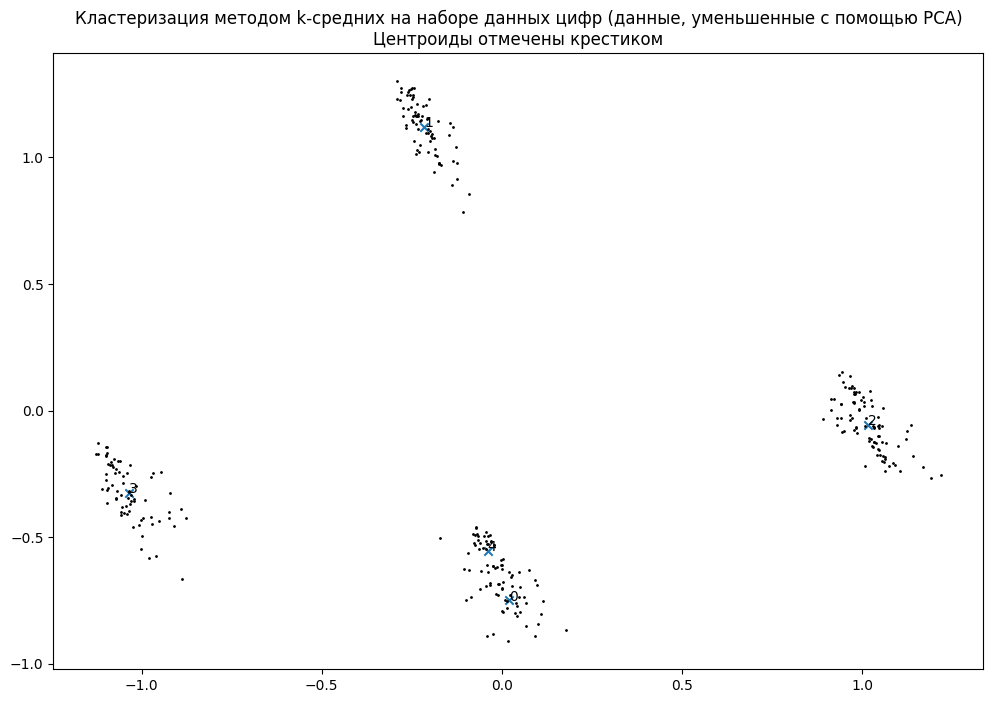

In [8]:
kmeans_model = KMeans(n_clusters=optimal_clusters,random_state=np.random.seed(42))

kmeans_model = kmeans_model.fit(df_encoded.values)

k_labels = kmeans_model.labels_
centroids = kmeans_model.cluster_centers_
centroids2d = pca_model.transform(kmeans_model.cluster_centers_)


plt.figure(figsize=(12,8))

plt.plot(W[:, 0], W[:, 1], "k.", markersize=2)
plt.scatter(centroids2d[:, 0],centroids2d[:, 1],marker="x")
for i, (x,y) in enumerate(centroids2d):
    plt.text(x,y,str(i))
plt.title("Кластеризация методом k-средних на наборе данных цифр (данные, уменьшенные с помощью PCA)\n""Центроиды отмечены крестиком")
plt.show()

**TASK 8**

*Реализуйте шаги 3-7 в виде функции или класса.*

In [9]:
class BaseballAnalyzer:
    def __init__(self, df_, random_state=42):
        """Инициализация анализатора данных бейсболистов"""
        self.random_state = random_state
        np.random.seed(random_state)

        self.df = df_        
        self.df_encoded = None
        self.linkage_matrix = None
        self.cluster_labels = None
        self.optimal_clusters = None
        self.pca_model = PCA(n_components=2)
        self.pca_results = None
        self.kmeans_model = None
        self.typical_representatives = {}

    @property
    def df_(self):
        return self.df
        
    def encode_features(self):
        """Шаг 3: Нормализация и кодирование признаков"""
        cat_cols = ['Team', 'League', 'Division', 'Position', 'Div']
        
        df_task3 = self.df.copy()
        
        num_cols = [col for col in self.df.columns if col not in cat_cols]
        
        scaler = MaxAbsScaler()
        df_task3[num_cols] = scaler.fit_transform(self.df[num_cols])
    
        self.df_encoded = pd.get_dummies(df_task3, columns=cat_cols, drop_first=True)
        self.scaler = scaler
        
        return self

    
    def perform_hierarchical_clustering(self):
        """Шаг 4: Иерархическая кластеризация"""
        self.linkage_matrix = linkage(self.df_encoded, method='average')
        
        plt.figure(figsize=(15, 7))
        dendrogram(self.linkage_matrix, truncate_mode='lastp', p=20)
        
        distance_threshold = sorted(self.linkage_matrix[:, 2])[-20]
        plt.axhline(y=distance_threshold, c='k', ls='--', lw=1)
        
        self.cluster_labels = fcluster(self.linkage_matrix, t=20, criterion='maxclust') - 1
        
        return self
    
    def find_optimal_clusters(self, max_clusters=20):
        """Шаг 5: Определение оптимального числа кластеров"""
        def sum_dist_to_center(X):
            center = np.mean(X, axis=0)
            return ((X - center) ** 2).sum()

        def choose_num_clusters_ahc(X, min_clust=2, max_clust=20):
            N = X.shape[0]
            Q = sum_dist_to_center(X)
            pseudo_f = []

            for G in range(min_clust, max_clust + 1):
                clustering = AgglomerativeClustering(
                    n_clusters=G,
                    linkage='average',
                    metric='euclidean'
                )
                labels = clustering.fit_predict(X)
                W = 0
                for l in range(G):
                    elems = X[labels == l]
                    W += sum_dist_to_center(elems)
                fisher_stat = ((Q - W) / (G - 1)) / (W / (N - G))
                pseudo_f.append(fisher_stat)

            pseudo_f = np.array(pseudo_f)
            cluster_range = np.arange(min_clust, max_clust + 1)


            local_maxima = argrelextrema(pseudo_f, np.greater)[0]
            if len(local_maxima) > 0:
                best_index = local_maxima[0]
            else:
                best_index = np.argmax(pseudo_f)

            k = cluster_range[best_index]

            plt.figure(figsize=(10, 5))
            plt.plot(cluster_range, pseudo_f, marker='o', label='Pseudo-F')
            plt.scatter(k, pseudo_f[best_index], color='red', s=80, label=f'k={k}')
            plt.xlabel('Число кластеров')
            plt.ylabel('Критерий Pseudo-F')
            plt.title('Зависимость Pseudo-F от количества кластеров')
            plt.grid(True)
            plt.legend()
            plt.show()

            print(f'Оптимальное количество кластеров: {k}')
            return k
        
        return self
    
    def visualize_with_pca(self):
        """Шаг 6: Визуализация с PCA"""
        self.pca_model = PCA(n_components=2)
        self.pca_results = self.pca_model.fit_transform(self.df_encoded.values)
        
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(
            self.pca_results[:, 0], 
            self.pca_results[:, 1],
            c=self.cluster_labels,
            cmap='Spectral',
            s=50
        )
        
        plt.colorbar(scatter, label='Cluster')
        plt.xlabel(f'PC1 ({self.pca_model.explained_variance_ratio_[0]:.2%} variance)')
        plt.ylabel(f'PC2 ({self.pca_model.explained_variance_ratio_[1]:.2%} variance)')
        plt.title('PCA проекция данных с цветовой кодировкой кластеров')
        
        return self
    
    def perform_kmeans(self, n_clusters=None):
        """Шаг 7: Кластеризация KMeans и поиск типичных представителей"""
        if n_clusters is None:
            n_clusters = self.optimal_clusters
        
        self.kmeans_model = KMeans(n_clusters=n_clusters, random_state=self.random_state)
        self.kmeans_model.fit(self.df_encoded.values)
        kmeans_labels = self.kmeans_model.labels_
        centroids = self.kmeans_model.cluster_centers_
        
        centroids_2d = self.pca_model.transform(centroids)
        
        for cluster_id in range(n_clusters):
            cluster_indices = np.where(kmeans_labels == cluster_id)[0]
            
            cluster_points = self.df_encoded.values[cluster_indices]
            distances = (((cluster_points - centroids[cluster_id])**2).sum(axis=1))**0.5
            
            min_dist_idx = cluster_indices[np.argmin(distances)]
            
            representative_name = self.df_encoded.index[min_dist_idx]
            self.typical_representatives[cluster_id] = representative_name
        
        plt.figure(figsize=(12, 8))
        plt.scatter(self.pca_results[:, 0], self.pca_results[:, 1], 
                   c=kmeans_labels, cmap='magma', s=50)
        
        plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], 
                  marker='X', s=100, color='white', edgecolor='black')
        
        for cluster_id, name in self.typical_representatives.items():
            idx = self.df_encoded.index.get_loc(name)
            plt.annotate(name, (self.pca_results[idx, 0], self.pca_results[idx, 1]),
                       xytext=(5, 5), textcoords='offset points')
        
        plt.title('K-means clustering (PCA-reduced data)')
        plt.colorbar(label='Cluster')
        
        print("Типичные представители кластеров:")
        for cluster_id, name in self.typical_representatives.items():
            print(f"Кластер {cluster_id}: {name}")
        
        return self

**TASK 9**

*Произведите дополнительную предобработку набора данных, сделав распределения переменных более симметричными. Для этого с помощью гисторамм или метода describe в dataframe или метода skew найдите переменные с одной модой и тяжелым правым хвостом, примените к ним преобразование log(1+x). Запустите функцию из шага 8. Как изменилось число кластеров, проекции и лучшие представители. Как считаете, субъективное качество кластеризации изменилось? Как и почему?*

array([[<Axes: title={'center': 'nAtBat'}>,
        <Axes: title={'center': 'nHits'}>,
        <Axes: title={'center': 'nHome'}>,
        <Axes: title={'center': 'nRuns'}>],
       [<Axes: title={'center': 'nRBI'}>,
        <Axes: title={'center': 'nBB'}>,
        <Axes: title={'center': 'YrMajor'}>,
        <Axes: title={'center': 'CrAtBat'}>],
       [<Axes: title={'center': 'CrHits'}>,
        <Axes: title={'center': 'CrHome'}>,
        <Axes: title={'center': 'CrRuns'}>,
        <Axes: title={'center': 'CrRbi'}>],
       [<Axes: title={'center': 'CrBB'}>,
        <Axes: title={'center': 'nOuts'}>,
        <Axes: title={'center': 'nAssts'}>,
        <Axes: title={'center': 'nError'}>],
       [<Axes: title={'center': 'Salary'}>,
        <Axes: title={'center': 'logSalary'}>, <Axes: >, <Axes: >]],
      dtype=object)

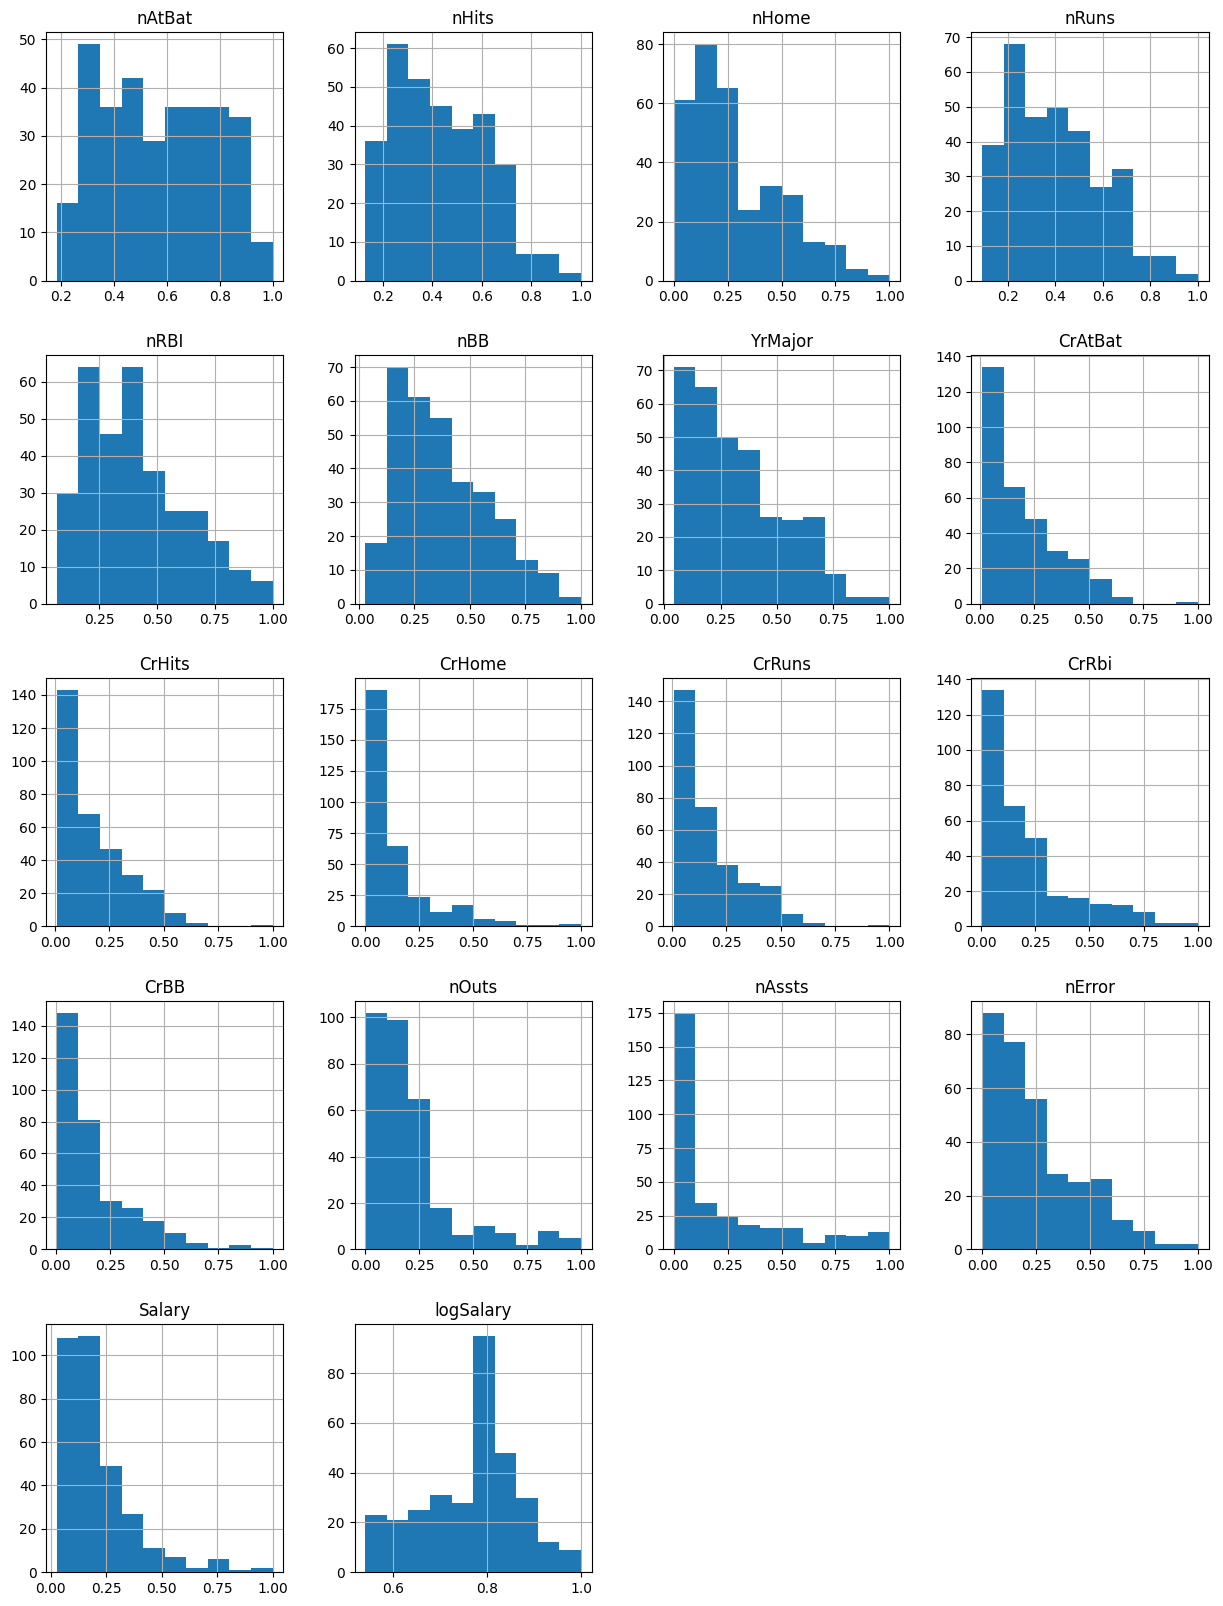

In [10]:
df_encoded.hist(figsize=(15,20))

Типичные представители кластеров:
Кластер 0: Moreland, Keith
Кластер 1: Slaught, Don
Кластер 2: Virgil, Ozzie
Кластер 3: Hassey, Ron
Кластер 4: Krenchicki, Wayne


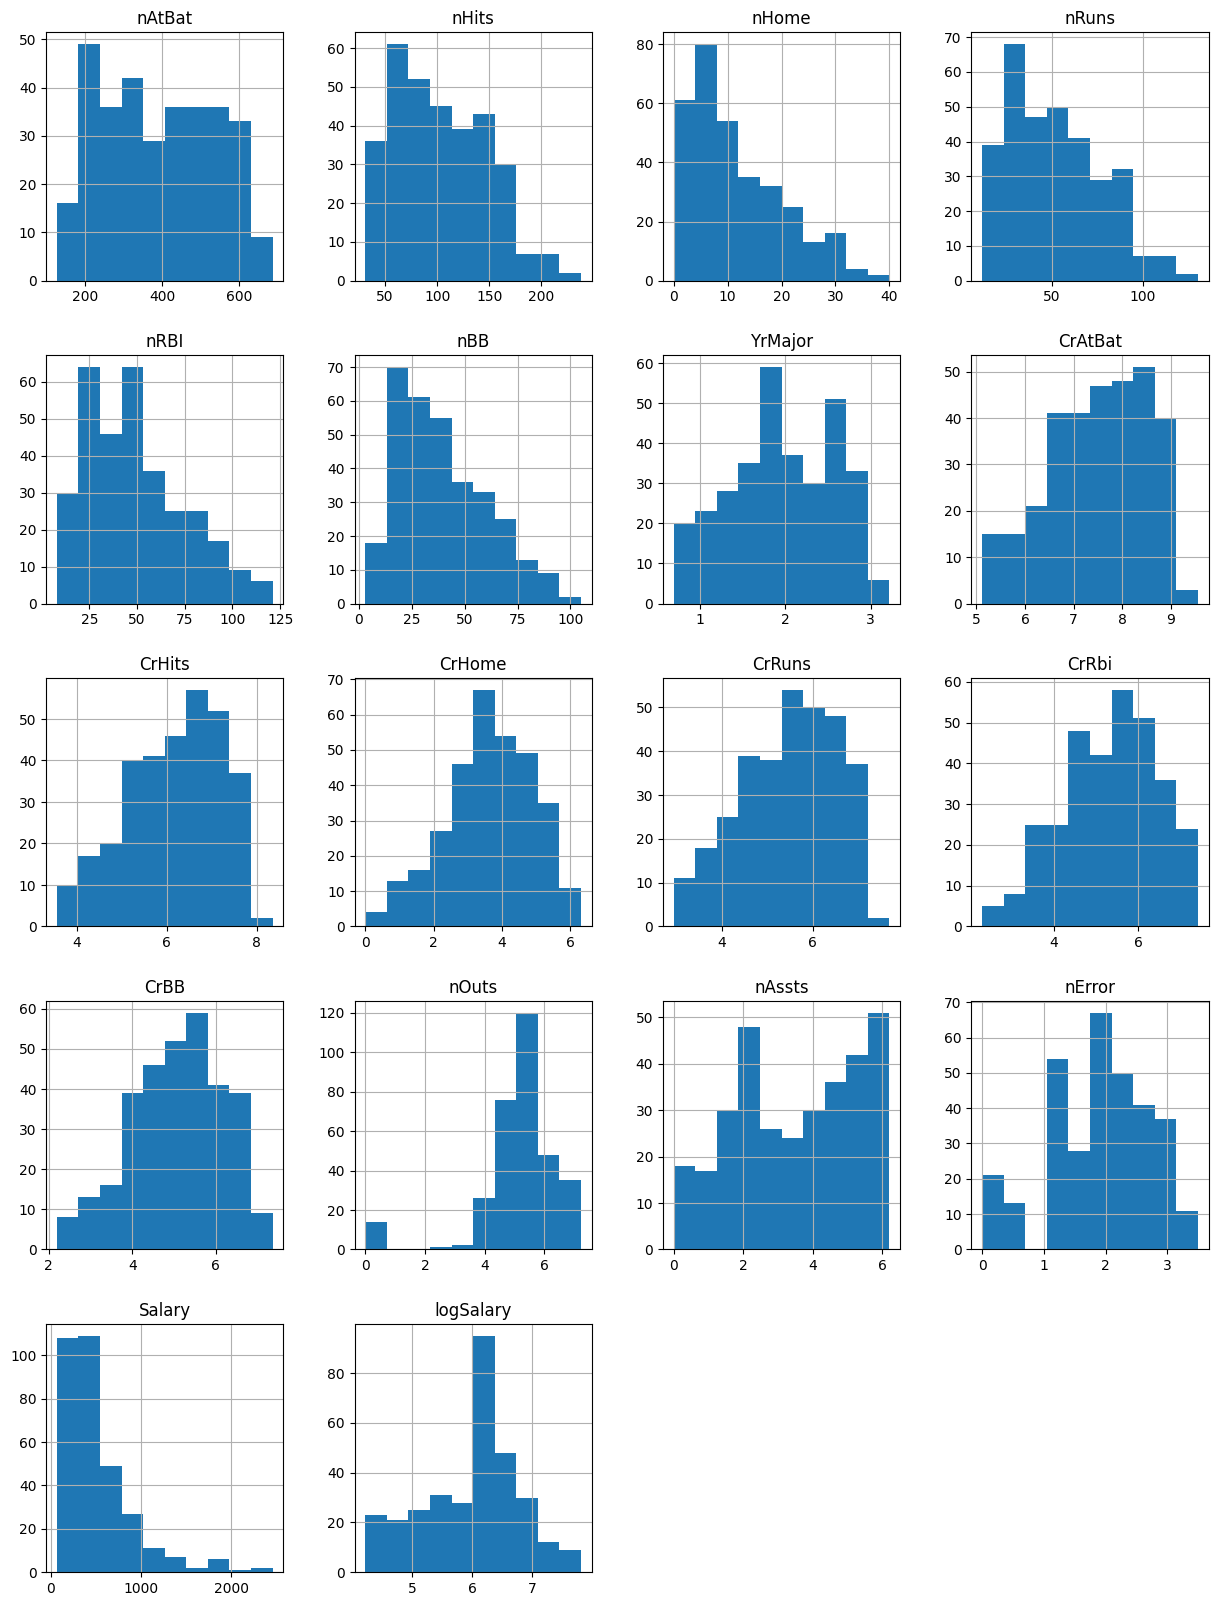

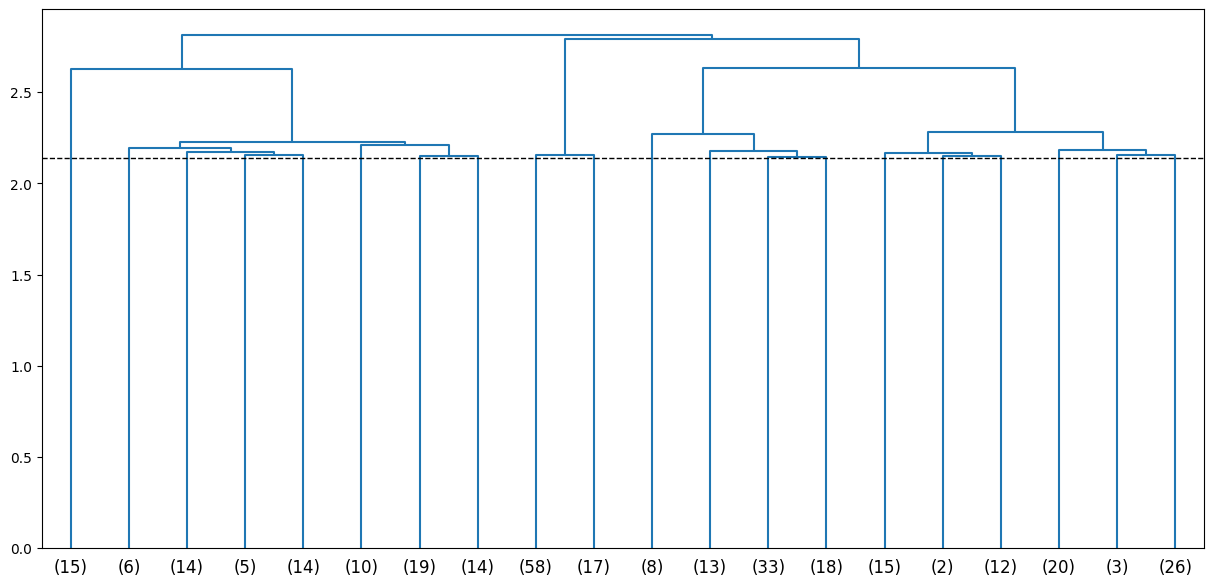

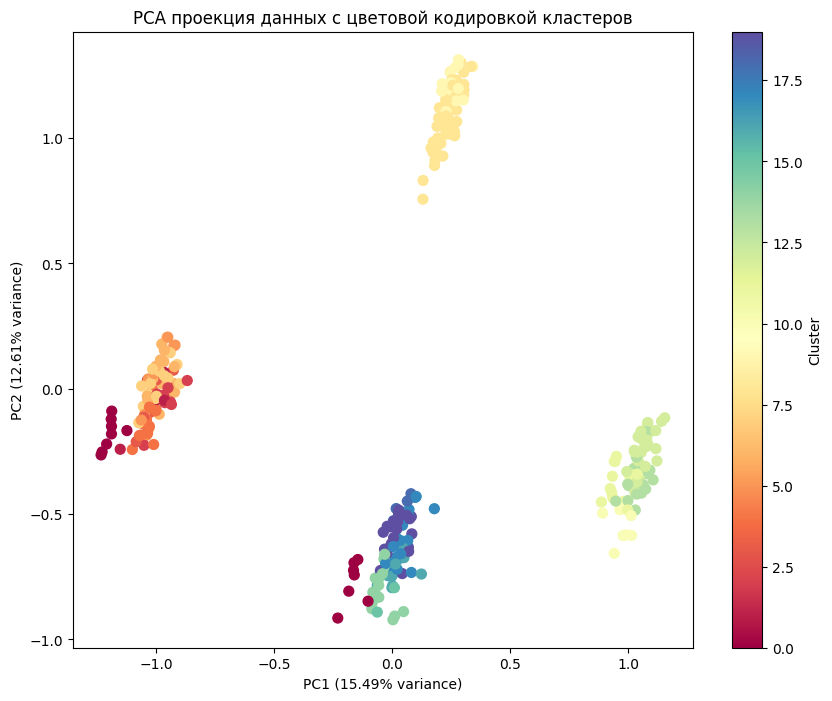

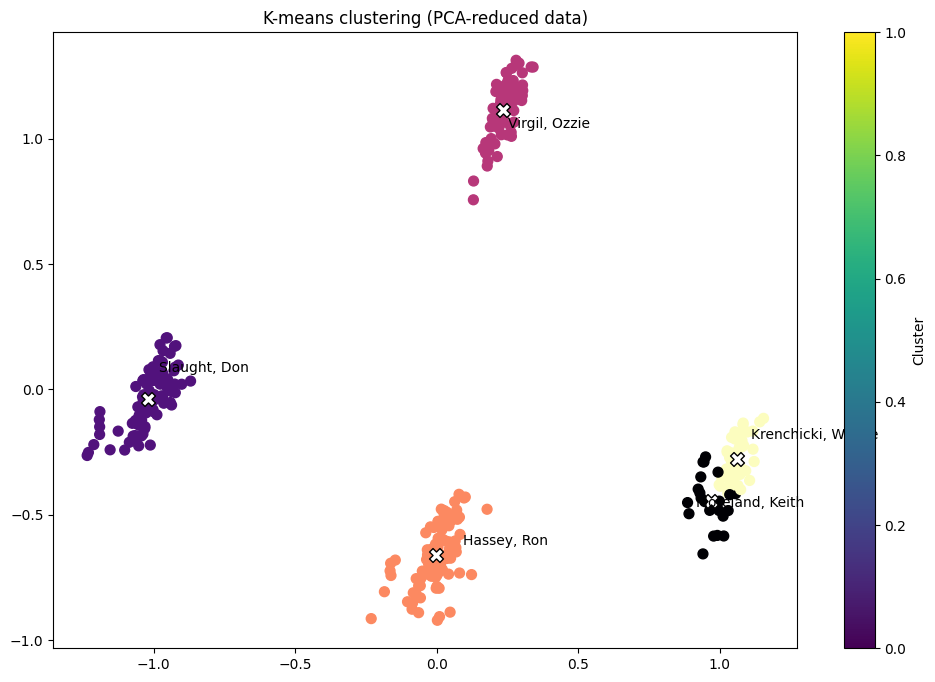

In [11]:
ne_norm = ['YrMajor','CrAtBat','CrHits','CrHome','CrRuns','CrRbi','CrBB','nOuts','nAssts','nError']

df[ne_norm] = df[ne_norm].apply(np.log1p)

cl = BaseballAnalyzer(df_=df,random_state=42)

cl.encode_features()
cl.df.hist(figsize=(15,20))
cl.perform_hierarchical_clustering()
cl.find_optimal_clusters()
cl.visualize_with_pca()
cl.perform_kmeans(n_clusters=5)


**TASK 10**

*Отберите число 5 наиболее значимых переменных с помощью метода VarClus. Запустите функцию из шага 8. Как изменилось число кластеров, проекции и лучшие представители. Как считаете, субъективное качество кластеризации изменилось? Как и почему?*

Типичные представители кластеров:
Кластер 0: Moreland, Keith
Кластер 1: Slaught, Don
Кластер 2: Virgil, Ozzie
Кластер 3: Hassey, Ron
Кластер 4: Krenchicki, Wayne


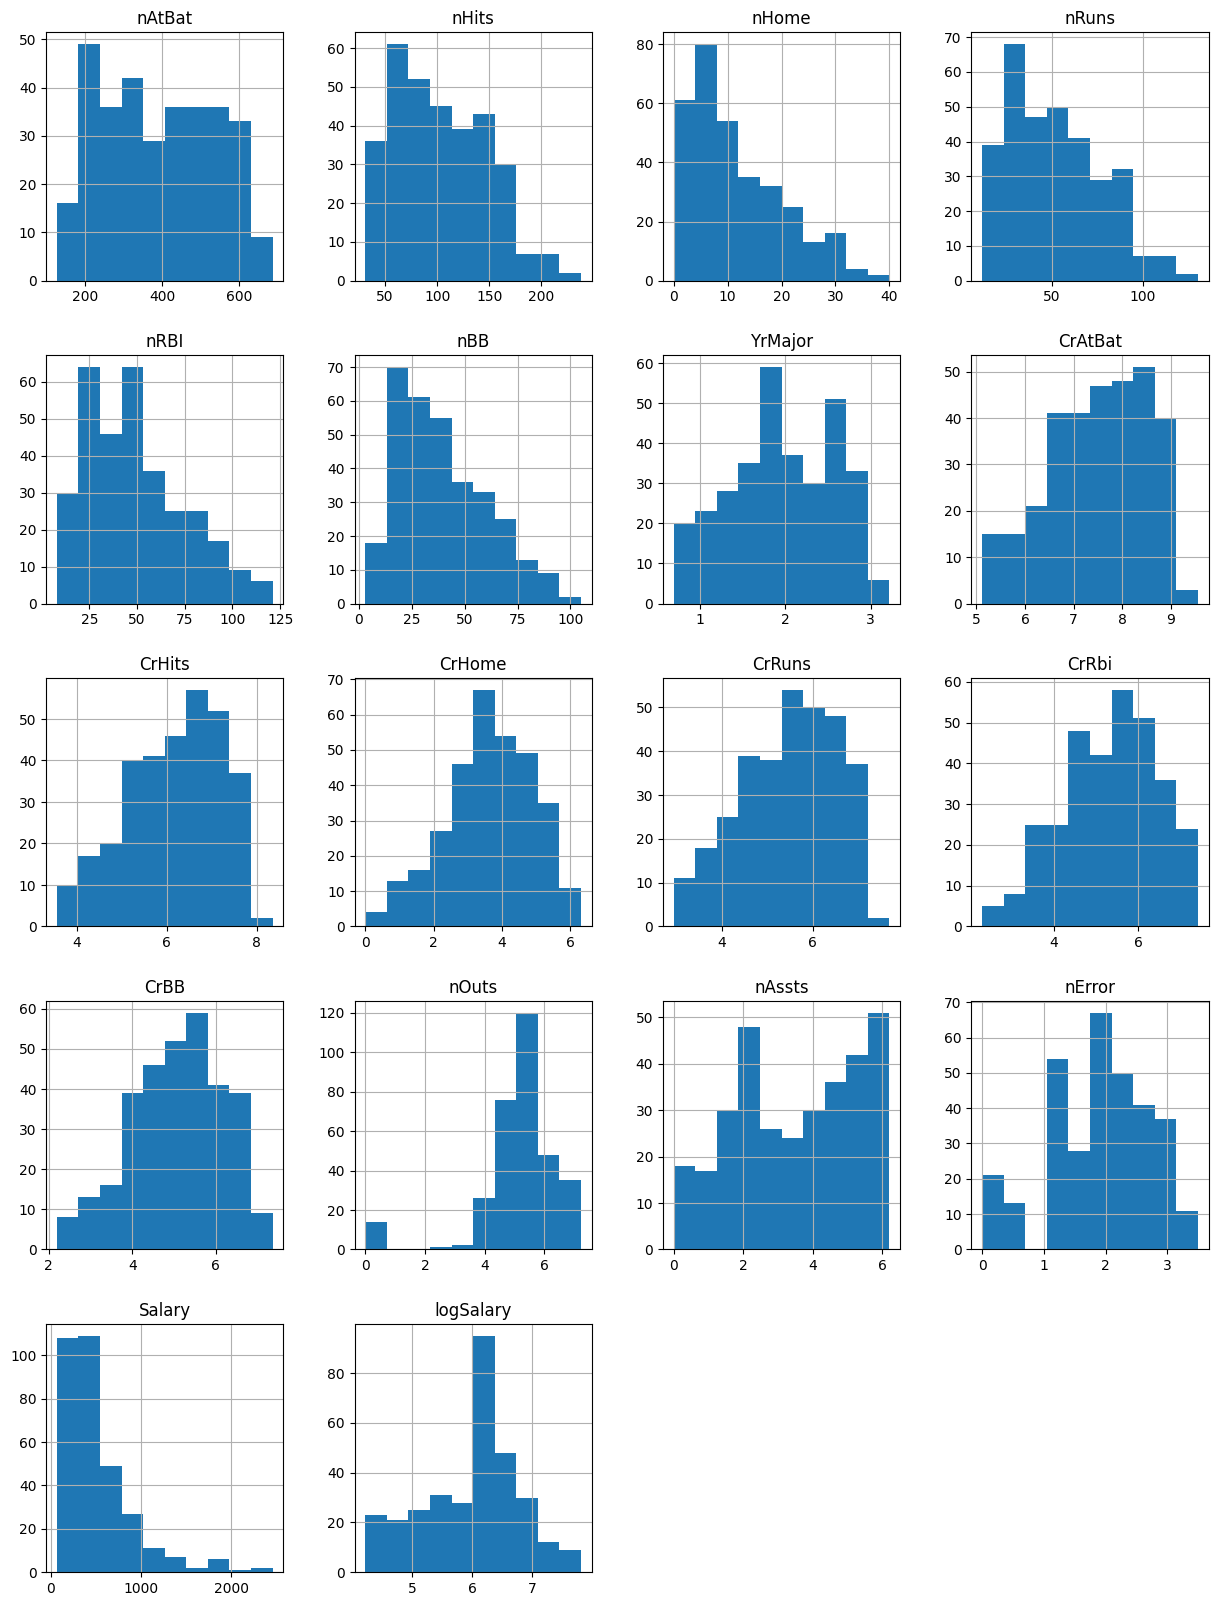

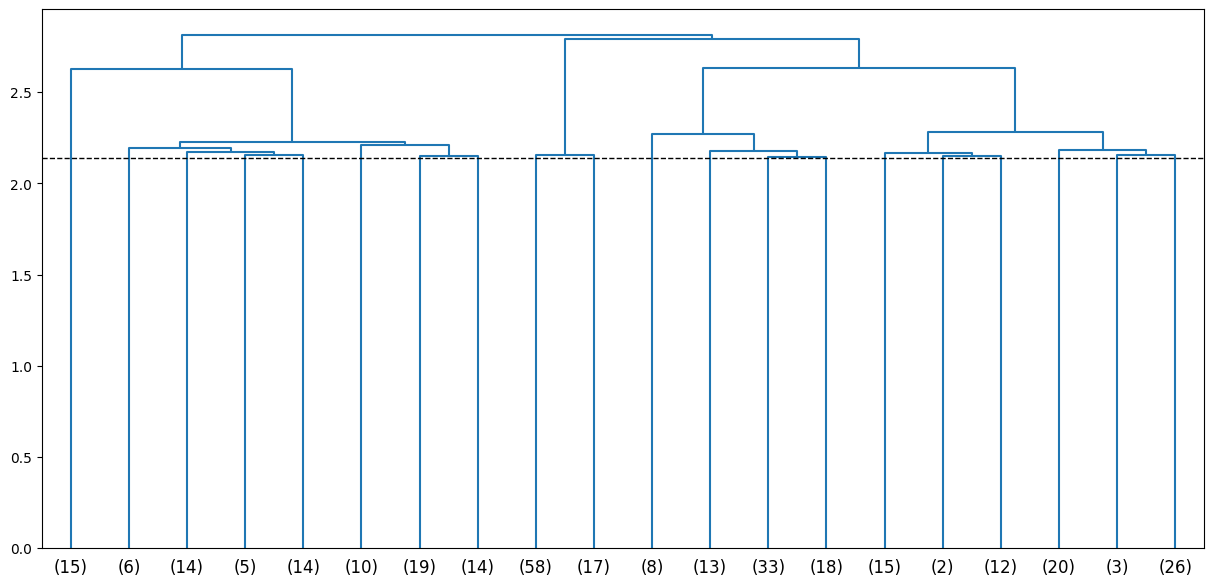

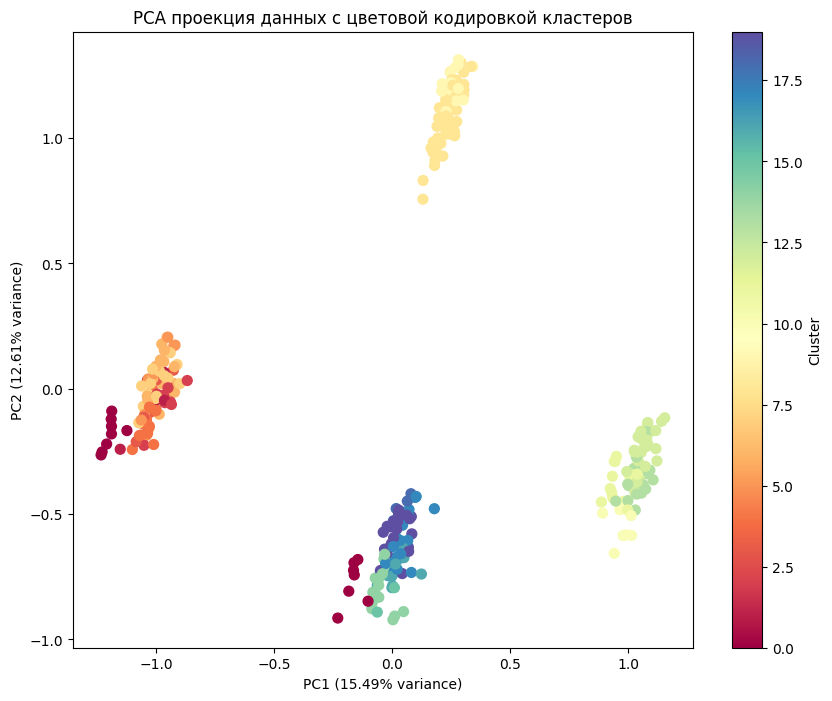

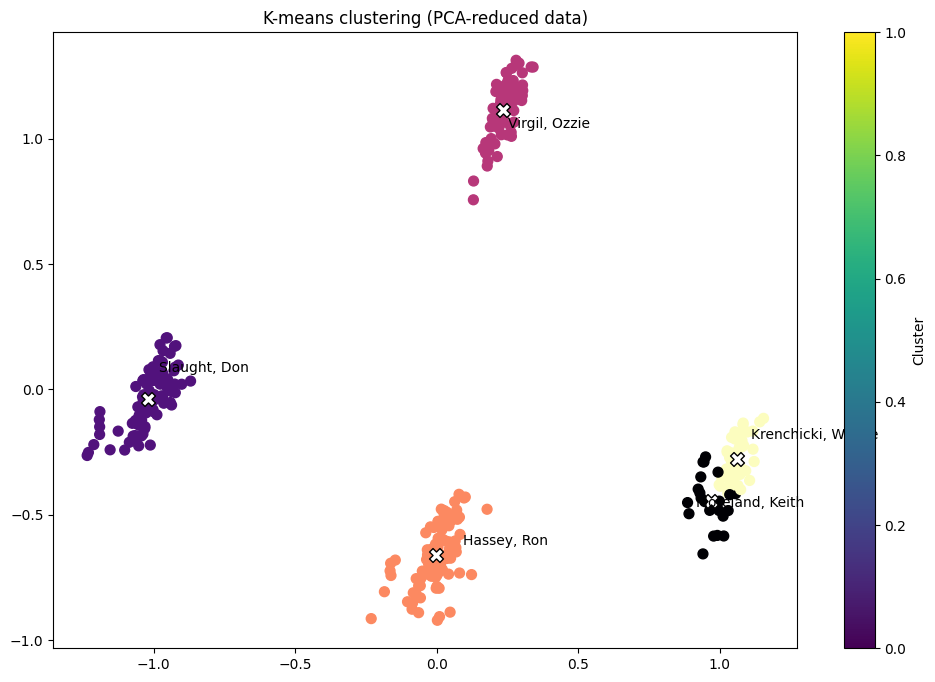

In [12]:
clusters = VarClusHi(df[num_cols], maxeigval2=0, maxclus=None)
clusters.varclus()
clusters.rsquare.loc[clusters.rsquare.groupby('Cluster')['RS_Ratio'].idxmin()]

cl = BaseballAnalyzer(df_=df,random_state=42)

cl.encode_features()
cl.df.hist(figsize=(15,20))
cl.perform_hierarchical_clustering()
cl.find_optimal_clusters()
cl.visualize_with_pca()
cl.perform_kmeans(n_clusters=5)

**TASK 11 (LAB 4)**

*«Творческое задание» на поиск аномалий. Загрузите файл mnist_small.csv. Данный набор данных содержит подмножество эталонного набора данных рукописных цифр MNIST. 5923 картинок 28x28 пикселей с изображением нуля и 76 картинок с изображением шестерки. Задача состоит в том, чтобы с использованием метода LOF построить одноклассовую модель на основе поиска аномалий, которая максимально хорошо отфильтрует шестерки (как аномалии) от нулей (как основной выборки). Признаки картинок описываются их координатами (в названии переменных, например «10x12») и значением яркости точки по этим координатам. Подбирая параметры метода и преобразуя признаки как посчитаете нужным, но не используя при этом информацию о label, постройте модель выявления аномалий с ERR EER (Equal Error Rate) меньше 0.2.*

In [13]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data = pd.read_csv('mnist_small.csv')

y = data['label']
X = data.drop('label',axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_zeros = X_pca[y == 0]
X_sixes = X_pca[y == 6]

In [15]:
lof_model = LocalOutlierFactor(n_neighbors=30, metric='euclidean', novelty=True, contamination=0.03)
lof_model.fit(X_zeros)

score = -lof_model.score_samples(X_pca)

y_true = np.zeros(len(y))
y_true[np.where(y == 6)[0]] = 1

fpr, tpr, thresholds = roc_curve(y_true, score)
fnr = 1 - tpr
idx = np.argmin(np.abs(fpr-fnr))
eer = (fpr[idx] + fnr[idx]) / 2

eer

np.float64(0.06564840896771727)

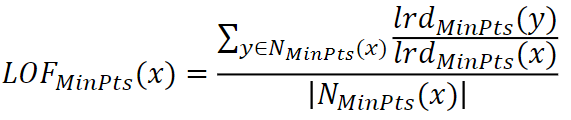

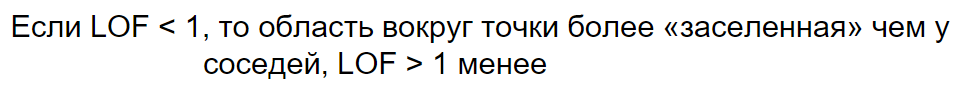

**TASK 12 (LAB 4)**

*Постройте ROC кривую с ERR EER. Выведите 4 картинки с числами (28 на 28 пикселей):*

*o самый типичный “0” – true negative с минимальной аномальностью*

*o самая аномальная “6” – true positive с максимальной аномальностью* 

*o самый нетипичный “0” – false positive с максимальной аномальностью* 

*o самая неаномальная “6” – false negative с минимальной аномальностью*

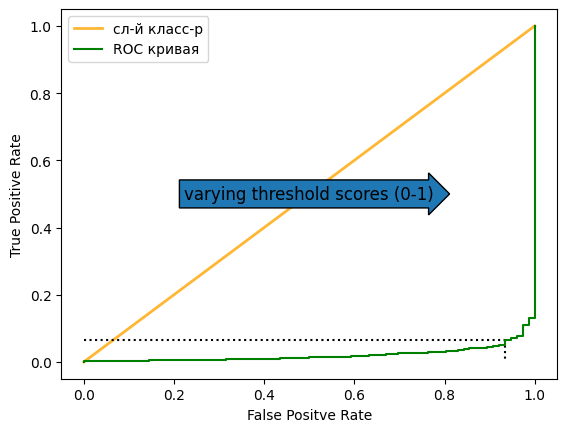

In [16]:
plt.plot([1, 0], [1, 0], linestyle='-', lw=2, color='orange',label='сл-й класс-р', alpha=.8)

plt.plot([1-eer,1-eer],[eer,0],linestyle='dotted',color='black')
plt.plot([0,1-eer],[eer,eer],linestyle='dotted',color='black')

plt.plot(tpr,fpr, label="ROC кривая",color="green")
plt.text(0.5, 0.5, "varying threshold scores (0-1)", rotation=0, size=12,ha="center", va="center",bbox=dict(boxstyle="rarrow"))
plt.xlabel("False Positve Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

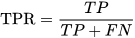

![alt text](image.png)

In [17]:

from sklearn.ensemble import IsolationForest 
from sklearn.metrics import roc_curve
isof = IsolationForest(contamination=0.01, random_state=42) 
isof.fit(data.drop(columns="label"))
X_Y = isof.score_samples (data.drop(columns="label"))
rc=roc_curve (data["label"], X_Y, pos_label=6)

fpr, tpr, threshold = rc
fnr = 1 - tpr
eer_threshold = threshold [np.nanargmin (np.absolute((fnr - fpr)))] 
EER = fpr[np.nanargmin(np.absolute((fnr - fpr)))]

In [18]:
zero_indices = np.where(y == 0)[0]
six_indices = np.where(y == 6)[0]

tzi_rel = np.argmax(score[zero_indices])
tzi = zero_indices[tzi_rel]

asi_rel = np.argmin(score[six_indices])
asi = six_indices[asi_rel]

azi_rel = np.argmin(score[zero_indices])
azi = zero_indices[azi_rel]

tsi_rel = np.argmax(score[six_indices])
tsi = six_indices[tsi_rel]


In [19]:
print(f"Размер данных X: {X.shape}")
print(f"Индексы: tzi={tzi}, asi={asi}, azi={azi}, tsi={tsi}")
print(f"Допустимый диапазон: 0 до {len(X)-1}")

Размер данных X: (5999, 784)
Индексы: tzi=43, asi=5966, azi=151, tsi=5995
Допустимый диапазон: 0 до 5998


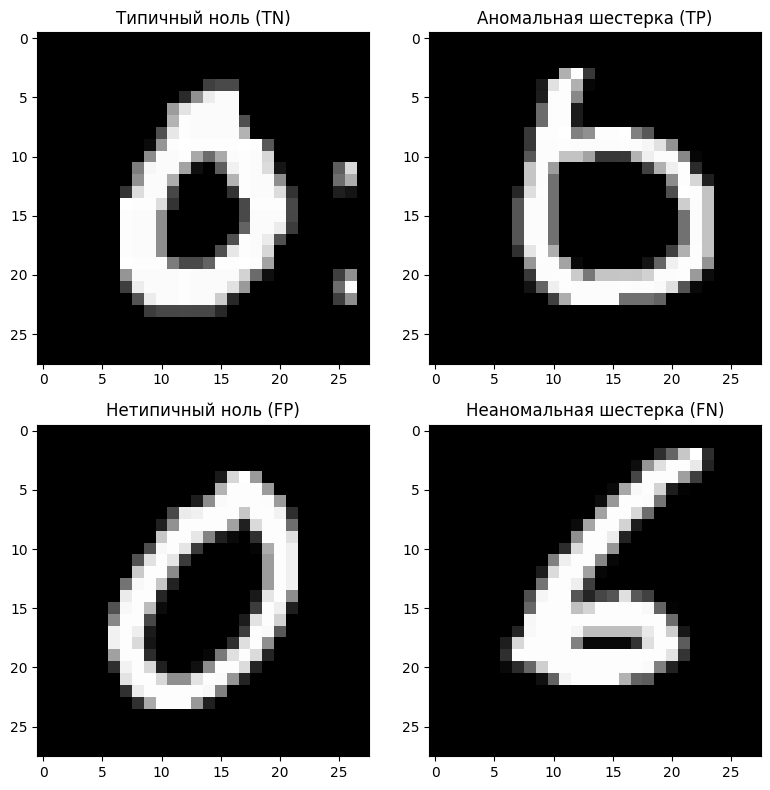

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))


axes[0, 0].imshow(X.iloc[tzi].values.reshape(28, 28), cmap='gray')
axes[0, 0].set_title('Типичный ноль (TN)')

axes[0, 1].imshow(X.iloc[asi].values.reshape(28, 28), cmap='gray')
axes[0, 1].set_title('Аномальная шестерка (TP)')

axes[1, 0].imshow(X.iloc[azi].values.reshape(28, 28), cmap='gray')
axes[1, 0].set_title('Нетипичный ноль (FP)')

axes[1, 1].imshow(X.iloc[tsi].values.reshape(28, 28), cmap='gray')
axes[1, 1].set_title('Неаномальная шестерка (FN)')

plt.tight_layout()
plt.show()
